In [1]:
# Importing all the necessary libraries 
import os 
import tarfile
import pandas as pd
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
SEED = 42

np.random.seed(42)

In [2]:
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

# Downloading my housing data
def fetch_housing_data(housing_url=HOUSING_URL,housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url,tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

# Loading the data using pandas
def loading_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)
housing = loading_housing_data()

In [3]:
# head
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# see what the ocean proximity entails
housing['ocean_proximity'].value_counts()
housing.shape

(20640, 10)

In [5]:
# understanding the data
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
# Getting to know what my datasets set contains ie features and columns 
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

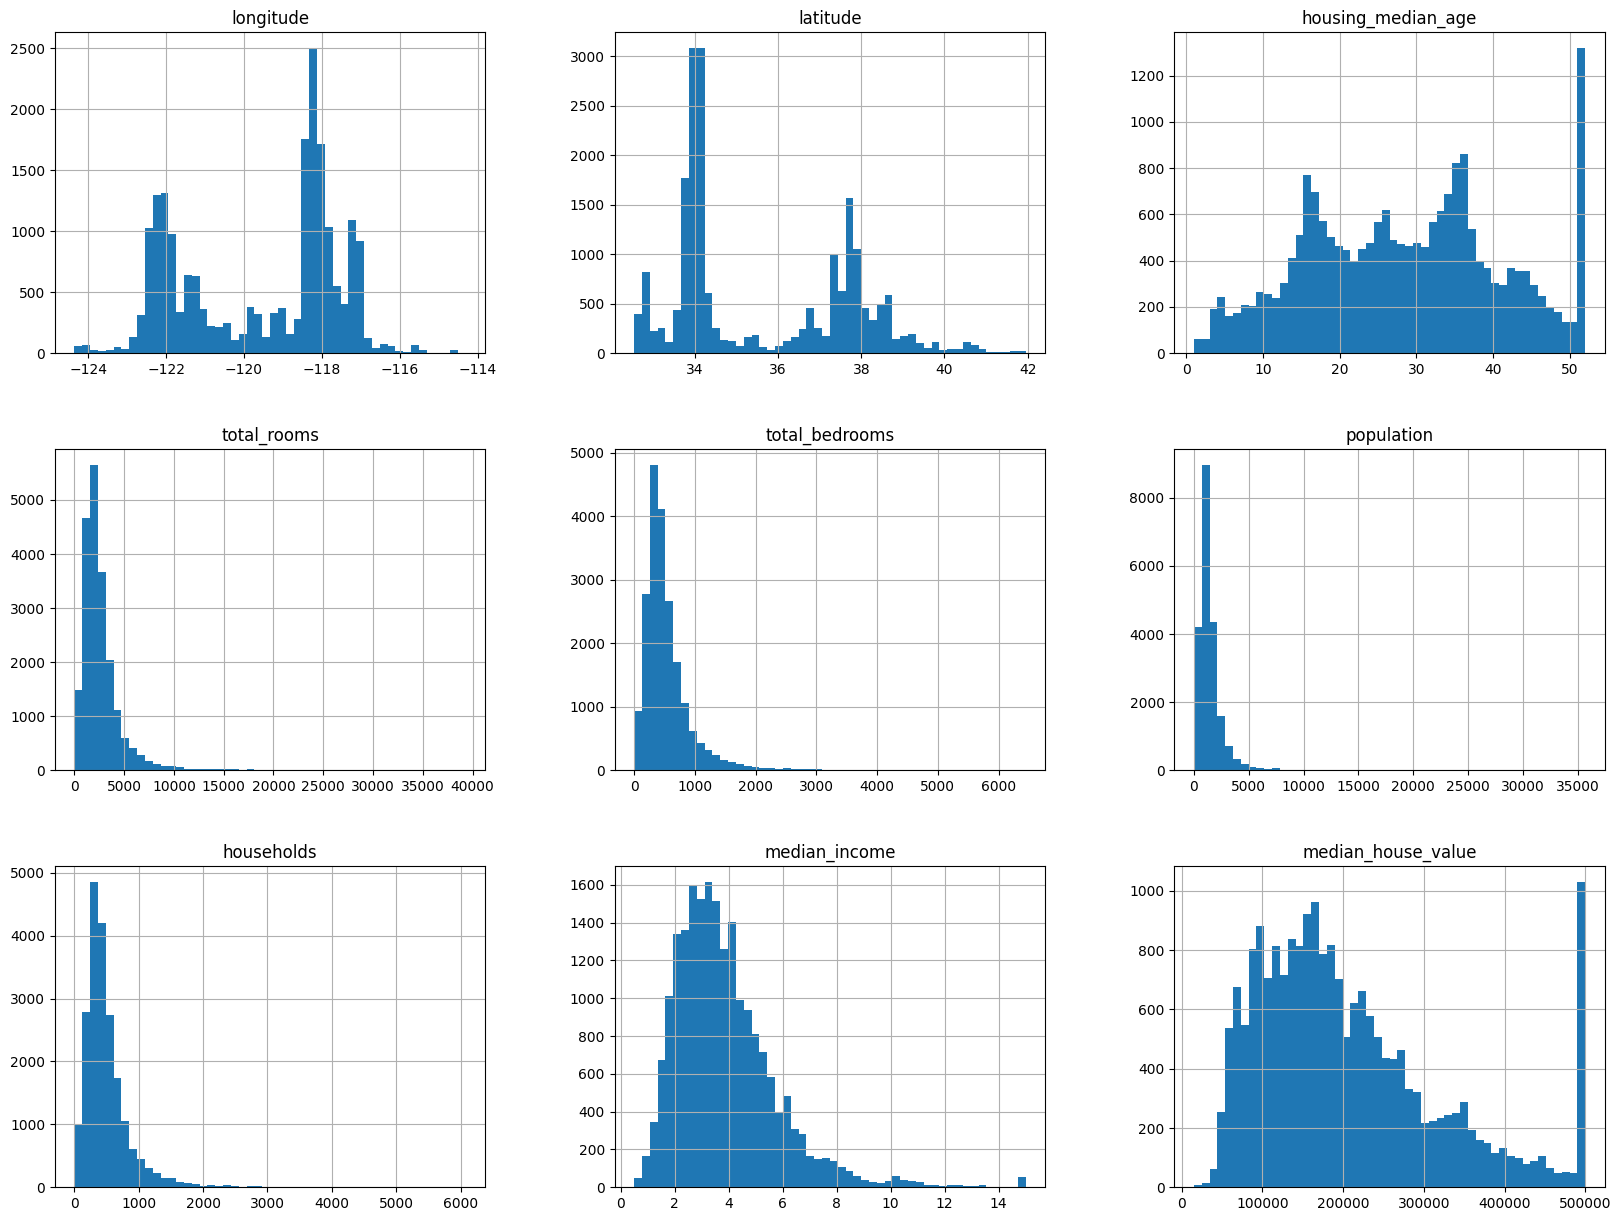

In [7]:
# Histogram to see how my datasets is distributed
housing.hist(bins=50,figsize=(20,15))

In [8]:
# Splitting the data using the stratified method
from sklearn.model_selection import StratifiedShuffleSplit
housing['income_cat'] = pd.cut(housing['median_income'],
                              bins=[0.0,1.5,3.0,4.5,6.0,np.inf],
                              labels=[1,2,3,4,5])
# housing['income_cat'].hist()
split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index,test_index in split.split(housing,housing['income_cat']):
    strat_train_set = housing.iloc[train_index]
    strat_test_set = housing.iloc[test_index]
# print(strat_test_set)
# print(strat_train_set)
housing = strat_train_set.copy()
# housing.head()
housing.drop('income_cat', axis=1,inplace=True)
print(housing.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12655    -121.46     38.52                29.0       3873.0           797.0   
15502    -117.23     33.09                 7.0       5320.0           855.0   
2908     -119.04     35.37                44.0       1618.0           310.0   
14053    -117.13     32.75                24.0       1877.0           519.0   
20496    -118.70     34.28                27.0       3536.0           646.0   

       population  households  median_income  median_house_value  \
12655      2237.0       706.0         2.1736             72100.0   
15502      2015.0       768.0         6.3373            279600.0   
2908        667.0       300.0         2.8750             82700.0   
14053       898.0       483.0         2.2264            112500.0   
20496      1837.0       580.0         4.4964            238300.0   

      ocean_proximity  
12655          INLAND  
15502      NEAR OCEAN  
2908           INLAND  
14053      NEAR OCEA

<Axes: xlabel='longitude', ylabel='latitude'>

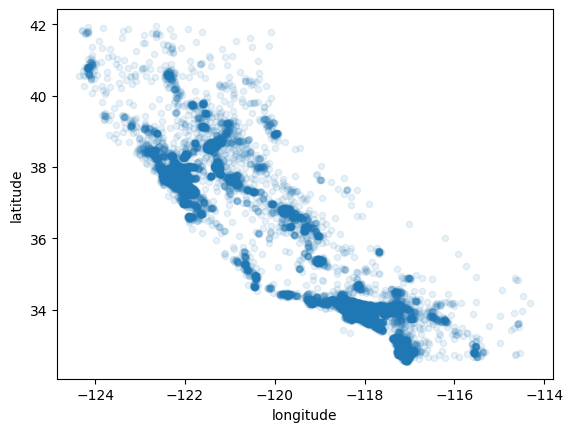

In [9]:
# Plotting scatter graph to see how the data is related
housing.plot(kind='scatter',x='longitude',y='latitude',alpha=0.1)

<Axes: xlabel='longitude', ylabel='latitude'>

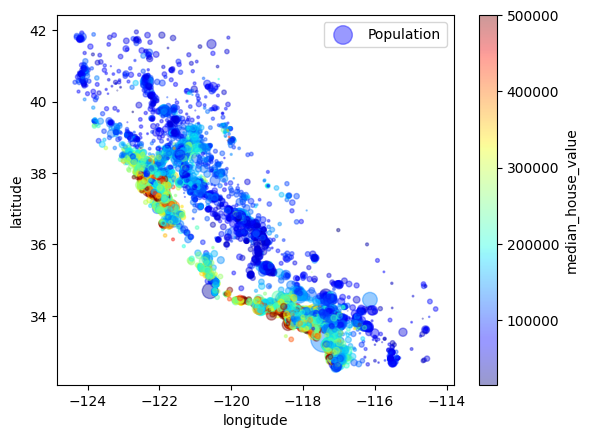

In [10]:
# Visualizing my datasets
housing.plot(kind='scatter',x='longitude',y='latitude',alpha=0.4,
            s= housing['population']/100,label='Population',
            c = 'median_house_value',cmap=plt.get_cmap('jet'),colorbar=True)

In [11]:
# Finding the correction 
corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(key=abs,ascending=False)

median_house_value    1.000000
median_income         0.687151
latitude             -0.142673
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
longitude            -0.047466
population           -0.026882
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

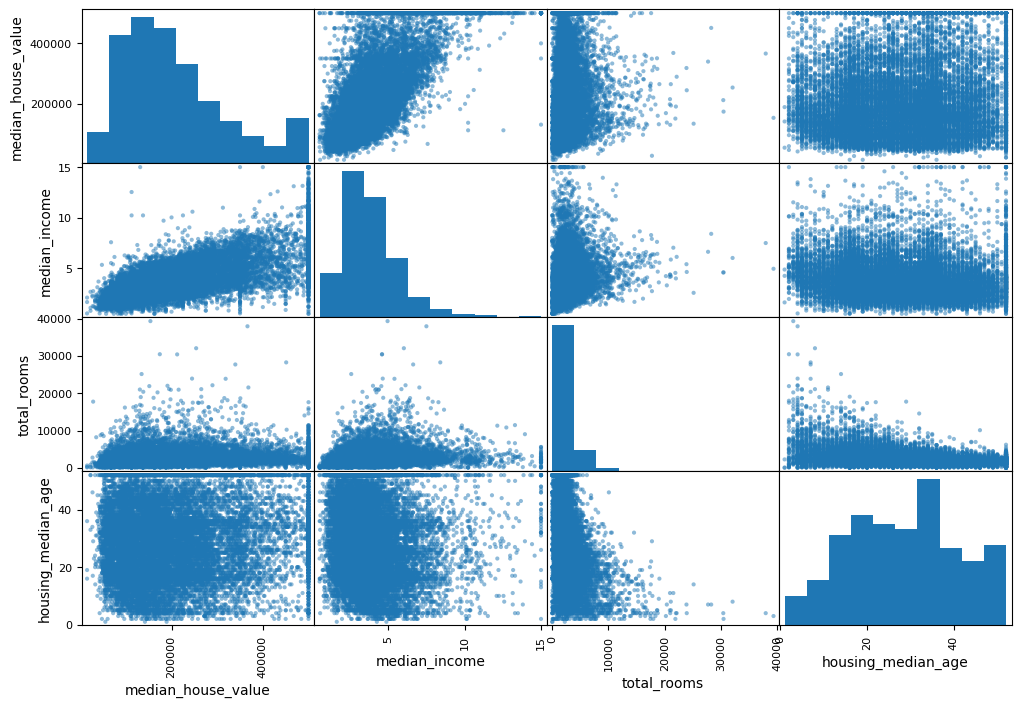

In [12]:
from pandas.plotting import scatter_matrix
attributes = ['median_house_value','median_income','total_rooms','housing_median_age']
scatter_matrix(housing[attributes],figsize=(12,8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

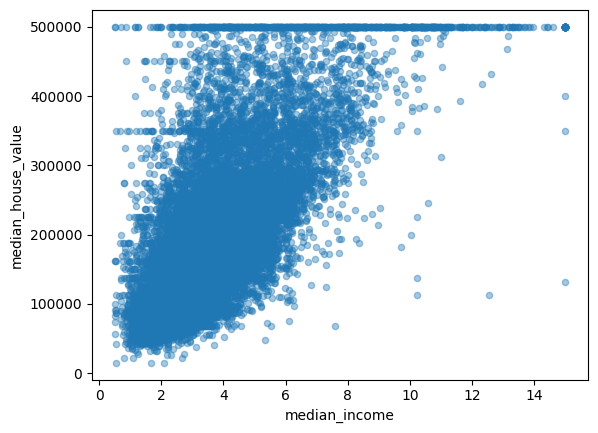

In [13]:
# Plotting the graph to find the correction of median_house_value and median income
housing.plot(kind='scatter',x='median_income',y='median_house_value',alpha=0.4)

In [14]:
# Dividing the data into housing labels and 
housing.head()
housing_num = housing.drop('ocean_proximity',axis=1)
housing_num.drop('median_house_value',axis=1,inplace=True)
# housing_num.head()
labels = housing['median_house_value']


In [15]:
# Creating custom transformer
from sklearn.base import BaseEstimator,TransformerMixin
rooms_ix,bedrooms_ix,population_ix,households_ix = 3,4,5,6
class CombinedAttributesAdder(BaseEstimator,TransformerMixin):
    def __init__(self,add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self,X,y=None):
        return self
    def transform(self,X,y=None):
        bedrooms_per_household = X[:,bedrooms_ix] / X[:,households_ix]
        population_per_household = X[:,population_ix] / X[:,households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:,bedrooms_ix] / X[:,rooms_ix]
            return np.c_[X,bedrooms_per_household,population_per_household,bedrooms_per_room]
        else:
            return np.c_[X,bedrooms_per_household,population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
house_extra_attribs = attr_adder.transform(housing.values)
print(house_extra_attribs)

[[-121.46 38.52 29.0 ... 'INLAND' 1.1288951841359773 3.168555240793201]
 [-117.23 33.09 7.0 ... 'NEAR OCEAN' 1.11328125 2.6236979166666665]
 [-119.04 35.37 44.0 ... 'INLAND' 1.0333333333333334 2.223333333333333]
 ...
 [-122.72 38.44 48.0 ... '<1H OCEAN' 0.9651162790697675
  2.6627906976744184]
 [-122.7 38.31 14.0 ... '<1H OCEAN' 1.157684630738523 2.411177644710579]
 [-122.14 39.97 27.0 ... 'INLAND' 1.1269035532994924 3.1725888324873095]]


In [16]:
# Numerical pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesAdder()),
    ('standard scaler', StandardScaler())
])
housing_num_pip = num_pipeline.fit_transform(housing_num)

In [17]:
# Creating the full pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
num_attribs = list(housing_num)
print(num_attribs)
cat_attribs = ['ocean_proximity']
print(cat_attribs)

full_pipeline = ColumnTransformer([
    ('num', num_pipeline,num_attribs),
    ('cat', OneHotEncoder(),cat_attribs)])
housing_final = full_pipeline.fit_transform(housing)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
['ocean_proximity']


In [18]:
# Creating the model
from sklearn.linear_model import LinearRegression
model1 = LinearRegression(random_state=42)
model1.fit(housing_final,labels)
prediction1 = model1.predict(housing_final)

In [19]:
# Evaluating the system
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(prediction1,labels)
rmse = np.sqrt(mse)
print(rmse)

68789.58126449553


In [20]:
# Trying different model
from sklearn.tree import DecisionTreeRegressor
model2 = DecisionTreeRegressor(random_state=42)
model2.fit(housing_final,labels)
prediction2 = model2.predict(housing_final)

In [21]:
# Using cross validation to analysis the models
def cross_validation(model,x,y):
    from sklearn.model_selection import cross_val_score

    scores = cross_val_score(model,x,y,
                            cv=10,
                            scoring='neg_mean_squared_error',
                            n_jobs=-1)
    
    rmse = np.sqrt(-scores)
    return rmse


In [22]:
def display_the_scores(scores):
    print('scores:', scores)
    print('mean:', scores.mean())
    print('standard deviation:', scores.std())


In [23]:
model2_rmse = cross_validation(model2,housing_final,labels)
display_the_scores(model2_rmse)

scores: [73782.38744698 72406.9995499  70303.69180093 71144.86825587
 68752.62013692 74866.313195   75254.78778525 72251.16836194
 70019.35700461 71938.04606996]
mean: 72072.02396073486
standard deviation: 2006.0940228783445


In [24]:
model1_rmse = cross_validation(model1,housing_final,labels)
display_the_scores(model1_rmse)

scores: [71801.99837884 65015.07583697 67659.2906864  68827.61774507
 67026.6711897  72547.86158248 75116.24236759 68966.54738073
 66561.96285809 70397.64938435]
mean: 69392.09174102091
standard deviation: 2929.3175034032483


In [25]:
# Using random forest model
from sklearn.ensemble import RandomForestRegressor
model3 = RandomForestRegressor(random_state=42)
model3.fit(housing_final,labels)
prediction3 = model3.predict(housing_final)

In [26]:
# Evaluating your model
model3_rmse_scores = cross_validation(model3,housing_final,labels)
display_the_scores(model3_rmse_scores)

scores: [52018.05612034 49694.66792129 46986.02421718 52297.04483496
 47665.27542924 51814.49350824 53044.54302941 49934.08505694
 48305.53586298 54602.74462172]
mean: 50636.247060229274
standard deviation: 2378.0563339566834


In [27]:
# using Grid search to fine tune the model
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = [
    {'n_estimators': [3,10,30], 'max_features': [2,4,6,8]},
    {'bootstrap': [False], 'n_estimators': [3,10], 'max_features': [2,3,4]}
]
model4 = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(model4,param_grid,
                           cv=5,
                          scoring='neg_mean_squared_error',
                        n_jobs = 1,
                          return_train_score = True
)

grid_search.fit(housing_final,labels)

model_prediction = grid_search.predict(housing_final)

final_model = grid_search.best_estimator_
final_prediction = final_model.predict(housing_final)

model4_rmse_scores = cross_validation(final_model,housing_final,labels)
display_the_scores(model4_rmse_scores)

scores: [51294.664685   48540.9032829  45234.97179011 50613.43922577
 48262.89963702 49401.08931153 51346.09971161 48501.88694605
 47395.82752344 53626.93904403]
mean: 49421.87211574608
standard deviation: 2256.4029527616917


In [28]:
model_rmse_scores = cross_validation(model4,housing_final,labels)
display_the_scores(model_rmse_scores)

scores: [51480.18326408 50103.60137439 47406.40459754 52426.56664121
 47734.67686306 51678.00845864 53111.69103125 49586.63037753
 48655.95249678 54660.66427647]
mean: 50684.43793809582
standard deviation: 2268.5069454279123


In [29]:
# Checking the best parameters
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

In [30]:
# Choosing the best model
grid_search.best_estimator_

,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
results = grid_search.cv_results_
for mean_score,params in zip(results['mean_test_score'],results['params']):
    print(np.sqrt(-mean_score),params)

64186.042431567425 {'max_features': 2, 'n_estimators': 3}
55285.76892698267 {'max_features': 2, 'n_estimators': 10}
52958.13161068413 {'max_features': 2, 'n_estimators': 30}
59764.756925541755 {'max_features': 4, 'n_estimators': 3}
53271.398701728656 {'max_features': 4, 'n_estimators': 10}
50457.133698782905 {'max_features': 4, 'n_estimators': 30}
59976.7513652926 {'max_features': 6, 'n_estimators': 3}
52064.721145638505 {'max_features': 6, 'n_estimators': 10}
49889.54057959245 {'max_features': 6, 'n_estimators': 30}
58704.93842551571 {'max_features': 8, 'n_estimators': 3}
52524.462162542324 {'max_features': 8, 'n_estimators': 10}
50299.047936734365 {'max_features': 8, 'n_estimators': 30}
62254.77939141216 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54208.240843568085 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
59786.43363843274 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52092.33127013664 {'bootstrap': False, 'max_features': 3, 'n_estimato

In [32]:
# Future importance
feature_importances = grid_search.best_estimator_.feature_importances_ 
feature_importances

array([7.88430029e-02, 7.29860156e-02, 4.09732763e-02, 1.98608616e-02,
       1.65174326e-02, 1.82973453e-02, 1.61516214e-02, 3.43059690e-01,
       2.54242142e-02, 1.03687385e-01, 8.33034385e-02, 1.21002114e-02,
       1.57456103e-01, 8.84321078e-05, 4.81101670e-03, 6.43995322e-03])

In [33]:
extra_attribs = ['room_per_household','population_per_household','bedrooms_per_room']
cat_encoder = full_pipeline.named_transformers_['cat']
cat_one_hot_attribs = list(cat_encoder.categories_[0])
# print(cat_one_hot_encoder)

attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances,attributes), reverse =True)

[(0.3430596895335772, 'median_income'),
 (0.15745610347687505, 'INLAND'),
 (0.10368738520861469, 'population_per_household'),
 (0.08330343848821518, 'bedrooms_per_room'),
 (0.07884300292728055, 'longitude'),
 (0.07298601561185215, 'latitude'),
 (0.04097327626852146, 'housing_median_age'),
 (0.02542421422212404, 'room_per_household'),
 (0.019860861567505286, 'total_rooms'),
 (0.018297345254290283, 'population'),
 (0.016517432580193687, 'total_bedrooms'),
 (0.01615162141217185, 'households'),
 (0.012100211415452715, '<1H OCEAN'),
 (0.006439953221940126, 'NEAR OCEAN'),
 (0.0048110167036177235, 'NEAR BAY'),
 (8.84321077680295e-05, 'ISLAND')]

In [34]:
# Choosing the final model
final_model = grid_search.best_estimator_

x_test = strat_test_set.drop('median_house_value',axis=1)
Y_test = strat_test_set['median_house_value'].copy()
X_test_prepared = full_pipeline.transform(x_test)

final_predictions = final_model.predict(X_test_prepared)

# model5_rmse = cross_validation(final_model,X_test_prepared,Y_test)
# score_display(model5_rmse)

final_mse = mean_squared_error(Y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
print(final_rmse)

47312.92769834557


In [35]:
import joblib

# Save your best trained model and data transformation pipeline
joblib.dump(final_model, "california_housing_model.pkl")
joblib.dump(full_pipeline, "full_pipeline.pkl")

print("Model and pipeline saved successfully!")

Model and pipeline saved successfully!


In [36]:
# 1. Load saved files
loaded_model = joblib.load("california_housing_model.pkl")
loaded_pipeline = joblib.load("full_pipeline.pkl")

# 2. Grab a sample house from your test set
sample_house = x_test.iloc[:2]
sample_labels = Y_test.iloc[:2]

# 3. Transform and predict
sample_prepared = loaded_pipeline.transform(sample_house)
predictions = loaded_model.predict(sample_prepared)

# 4. Compare predictions with actual values
for pred, actual in zip(predictions, sample_labels):
    print(f"Predicted Price: ${pred:,.2f} | Actual Price: ${actual:,.2f}")

Predicted Price: $494,767.57 | Actual Price: $500,001.00
Predicted Price: $231,910.07 | Actual Price: $162,500.00


In [37]:
from scipy import stats
import numpy as np

confidence = 0.95
squared_errors = (final_predictions - Y_test) ** 2

confidence_interval = np.sqrt(
    stats.t.interval(
        confidence,
        len(squared_errors) - 1,
        loc=squared_errors.mean(),
        scale=stats.sem(squared_errors),
    )
)

print(f"95% Confidence Interval: {confidence_interval}")

95% Confidence Interval: [45350.26358017 49197.35610769]
